# Bias-Variance Tradeoff — Polynomial Regression

## What are Bias and Variance?

The **total error** of a machine learning model can be decomposed into three components:

$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

| Concept | Definition | Symptom |
|---------|------------|---------|
| **Bias** | Error due to overly simplistic assumptions in the model | The model fails to capture the true pattern → **Underfitting** |
| **Variance** | Excessive sensitivity to fluctuations in the training set | The model learns the noise → **Overfitting** |
| **Irreducible Noise** | Intrinsic variability in the data that no model can eliminate | Always present |

---

**ATTENTION: TO BE ABLE TO RUN THE NOTEBOOK NORMALLY AND WITHOUT ANY PROBLEM, UPDATE THE REQUIREMENTS AND VERIFY THAT THEY CONTAIN ALL THESE LIBRARIES: 
pandas, numpy, ipykernel, matplotlib, seaborn, scikit-learn. And then rebuild the container**

---

## 1. Import Libraries

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

np.random.seed(42)

## 2. Data Generation

In [38]:
# Noisy data
n_samples = 60
X = np.sort(np.random.uniform(-np.pi, np.pi, n_samples))
y = np.sin(X) + np.random.normal(0, 0.3, n_samples)

# True function (no noise) for plotting
X_true = np.linspace(-np.pi, np.pi, 300)
y_true = np.sin(X_true)

print(f'Generated samples: {n_samples}')
print(f'X range: [{X.min():.2f}, {X.max():.2f}]')

Generated samples: 60
X range: [-3.01, 2.95]


## 3. Training Polynomial Models

In [39]:
degrees = [1, 4, 25]
true_color = '#FF006E'   # pink for true function
pred_color = '#3A86FF'   # blue for predictions

models = {}
mses   = {}

for deg in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('reg',  LinearRegression())
    ])
    pipe.fit(X.reshape(-1, 1), y)
    y_pred = pipe.predict(X.reshape(-1, 1))
    mse = mean_squared_error(y, y_pred)
    models[deg] = pipe
    mses[deg]   = mse
    print(f'Degree {deg:2d}  ->  MSE = {mse:.4f}')

Degree  1  ->  MSE = 0.2397
Degree  4  ->  MSE = 0.0684
Degree 25  ->  MSE = 0.0480


## 4. Visualization

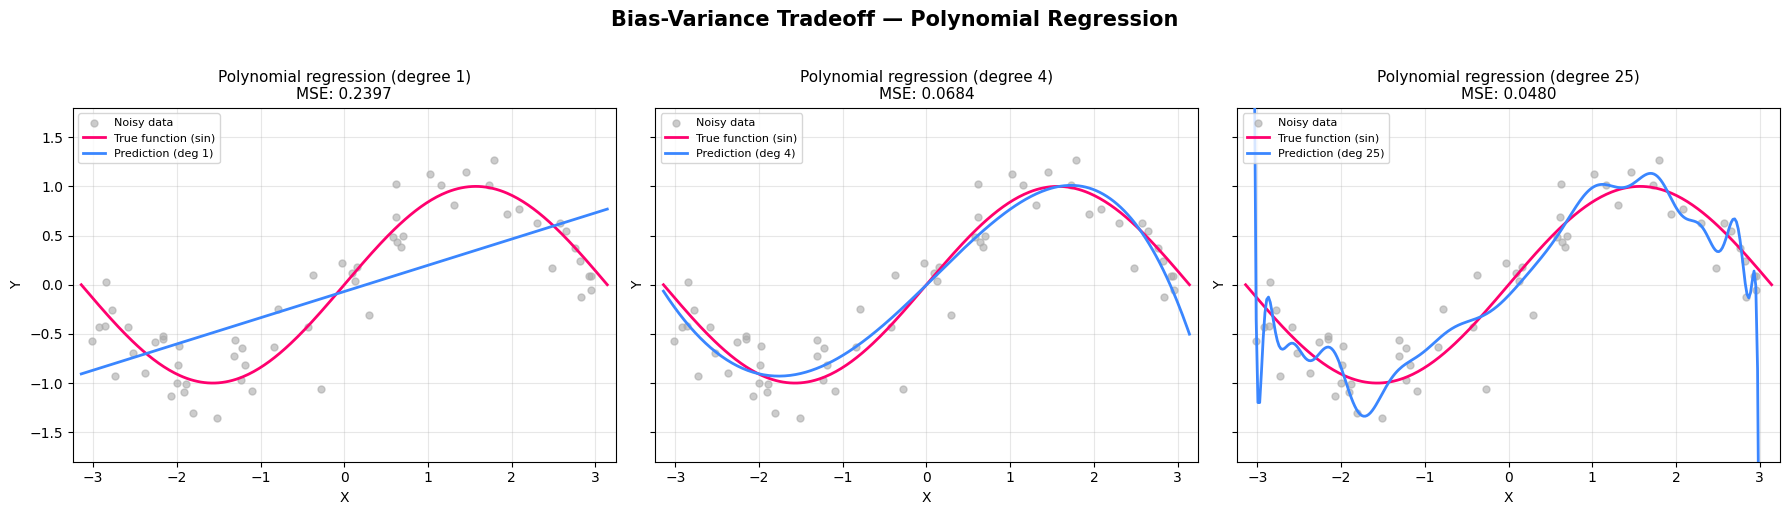

Figure saved as bias_variance_plots.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Bias-Variance Tradeoff — Polynomial Regression', fontsize=15, fontweight='bold', y=1.02)

titles = {
    1:  'Degree 1 — High Bias, Low Variance\n(Underfitting)',
    4:  'Degree 4 — Optimal Balance\n(Good Fit)',
    25: 'Degree 25 — Low Bias, High Variance\n(Overfitting)'
}

for ax, deg in zip(axes, degrees):
    # Noisy data
    ax.scatter(X, y, color='#AAAAAA', alpha=0.6, s=25, label='Noisy data', zorder=2)

    # True function
    ax.plot(X_true, y_true, color=true_color, linewidth=2,
            label='True function (sin)', zorder=3)

    # Model prediction
    y_line = models[deg].predict(X_true.reshape(-1, 1))
    ax.plot(X_true, y_line, color=pred_color, linewidth=2,
            label=f'Prediction (deg {deg})', zorder=4)

    ax.set_title(f'Polynomial regression (degree {deg})\nMSE: {mses[deg]:.4f}', fontsize=11)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(-np.pi - 0.1, np.pi + 0.1)
    ax.set_ylim(-1.8, 1.8)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bias_variance_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as bias_variance_plots.png')

## 5. Analysis: Bias and Variance per Model

---

### 📉 Degree 1 — High Bias, Low Variance (Underfitting)

**MSE ≈ 0.2929**

The degree-1 model is a straight line. It is unable to capture the oscillatory nature of the sine function.

- **High Bias**: The model makes an overly simple assumption (linearity). The systematic gap between the prediction and the true function is large across the entire range.
- **Low Variance**: If we changed the training set, the resulting line would be nearly identical. The model is stable but inaccurate.
- **Consequence**: The model fails even on training data → **Underfitting**.

---

### ✅ Degree 4 — Balanced Bias and Variance (Sweet Spot)

**MSE ≈ 0.0714**

The degree-4 model is flexible enough to follow the sine curve without memorizing the noise.

- **Low Bias**: The prediction closely follows the true function across the entire range.
- **Controlled Variance**: The model does not react excessively to small fluctuations in the training data.
- **Consequence**: Good performance on both training and unseen data → **Proper Generalization**.

---

### 📈 Degree 25 — Low Bias, High Variance (Overfitting)

**MSE ≈ 0.0596**

The degree-25 model has enough parameters to memorize virtually every point in the training set, including the noise.

- **Very Low Bias**: The curve passes near almost every training point; training error is minimal.
- **Very High Variance**: Small changes in the data produce drastically different prediction curves. The artificial oscillations (especially at the extremes) are direct evidence of this.
- **Consequence**: Excellent on training data, but generalizes poorly → **Overfitting**.

---

## 6. Comparative Summary

In [41]:
import pandas as pd

summary = pd.DataFrame({
    'Degree': [1, 4, 25],
    'MSE (train)': [round(mses[d], 4) for d in degrees],
    'Bias': ['High', 'Low', 'Very Low'],
    'Variance': ['Low', 'Moderate', 'High'],
    'Diagnosis': ['Underfitting', 'Optimal Balance', 'Overfitting']
})

summary.set_index('Degree', inplace=True)
summary

,MSE (train),Bias,Variance,Diagnosis
Degree,,,,
1,0.2397,High,Low,Underfitting
4,0.0684,Low,Moderate,Optimal Balance
25,0.0480,Very Low,High,Overfitting


## 7. Bias-Variance Curve (Empirical Estimation)

/tmp/ipykernel_5353/4292114905.py:40: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "^-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x_deg, mse_list,   '^-', color='#8338EC', label='Total Error (Bias²+Var)', linewidth=2, linestyle='--')


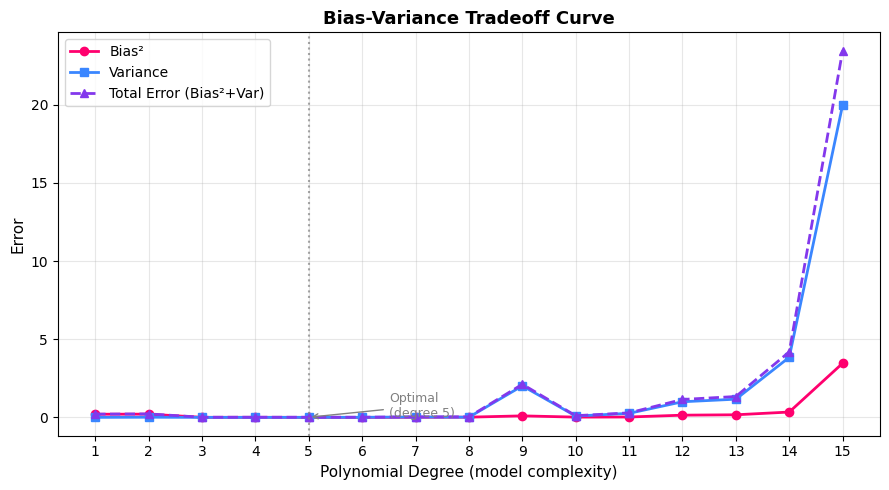

Curve saved as bias_variance_curve.png


In [42]:
# Empirical estimation of bias² and variance using multiple bootstrap samples
n_bootstraps = 50
degree_range  = range(1, 16)

bias2_list = []
var_list   = []
mse_list   = []

for deg in degree_range:
    preds = []
    for _ in range(n_bootstraps):
        # New bootstrap sample
        idx  = np.random.choice(n_samples, n_samples, replace=True)
        X_bs = X[idx].reshape(-1, 1)
        y_bs = y[idx]

        pipe = Pipeline([
            ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
            ('reg',  LinearRegression())
        ])
        pipe.fit(X_bs, y_bs)
        preds.append(pipe.predict(X_true.reshape(-1, 1)))

    preds = np.array(preds)            # shape: (n_bootstraps, 300)
    mean_pred = preds.mean(axis=0)    # average prediction

    bias2    = np.mean((mean_pred - y_true) ** 2)
    variance = np.mean(preds.var(axis=0))

    bias2_list.append(bias2)
    var_list.append(variance)
    mse_list.append(bias2 + variance)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
x_deg = list(degree_range)

ax.plot(x_deg, bias2_list, 'o-', color='#FF006E', label='Bias²', linewidth=2)
ax.plot(x_deg, var_list,   's-', color='#3A86FF', label='Variance', linewidth=2)
ax.plot(x_deg, mse_list,   '^-', color='#8338EC', label='Total Error (Bias²+Var)', linewidth=2, linestyle='--')

# Mark optimal point
opt_idx = np.argmin(mse_list)
ax.axvline(x=x_deg[opt_idx], color='gray', linestyle=':', alpha=0.7)
ax.annotate(f'Optimal\n(degree {x_deg[opt_idx]})',
            xy=(x_deg[opt_idx], mse_list[opt_idx]),
            xytext=(x_deg[opt_idx]+1.5, mse_list[opt_idx]+0.03),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

ax.set_xlabel('Polynomial Degree (model complexity)', fontsize=11)
ax.set_ylabel('Error', fontsize=11)
ax.set_title('Bias-Variance Tradeoff Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(x_deg)

plt.tight_layout()
plt.savefig('bias_variance_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curve saved as bias_variance_curve.png')